# Private Aggregation of Teacher Ensembles

In [1]:
import os
import io
import contextlib
import json
import shutil
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from safetensors.torch import save_file, load_file
from tqdm import tqdm

from htb_ai_library import (
    set_reproducibility, use_htb_style,
    MLP, get_mnist_loaders,
    create_dataloader, train_model, evaluate_accuracy, get_model_predictions,
    HTB_GREEN, NODE_BLACK, HACKER_GREY, WHITE,
    AZURE, MALWARE_RED, AQUAMARINE, NUGGET_YELLOW,
)

In [2]:
print("=" * 60)
print("PATE: PRIVATE AGGREGATION OF TEACHER ENSEMBLES")
print("Teacher-Student Privacy Through Knowledge Distillation")
print("=" * 60)

PATE: PRIVATE AGGREGATION OF TEACHER ENSEMBLES
Teacher-Student Privacy Through Knowledge Distillation


In [3]:
RANDOM_SEED = 1337
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_reproducibility(RANDOM_SEED)
use_htb_style()

PLOT_CONFIG = {"figsize": (10, 6), "dpi": 150}
DATASET_CONFIG = {"name": "mnist", "num_classes": 10, "num_features": 784}
DATA_DIR = "./data"
TEACHERS_SAVE_DIR = os.path.join(DATA_DIR, "pate_teachers")
# Set to True to ignore saved teachers and retrain from scratch
FORCE_RETRAIN_TEACHERS = False

In [4]:
TEACHER_CONFIG = {
    "num_teachers": 250,  # Original paper configuration
    "hidden_layers": [128, 64],
    "dropout": 0.2,
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 0.001,
}

AGGREGATION_CONFIG = {
    "noise_scale": 20.0,  # Strong privacy with high consensus
    "num_student_queries": 5000,
}

STUDENT_CONFIG = {
    "hidden_layers": [128, 64],
    "dropout": 0.2,
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 0.001,
}


## Data Partitioning and Teacher Training

In [5]:
print("\n" + "=" * 60)
print("PHASE 1: Loading MNIST Dataset")
print("=" * 60)

# Remove corrupted MNIST cache so torchvision can re-download cleanly
mnist_cache = os.path.join(DATA_DIR, "MNIST")
if os.path.isdir(mnist_cache):
    shutil.rmtree(mnist_cache)
    print("Removed existing MNIST cache for fresh download.")
os.makedirs(DATA_DIR, exist_ok=True)

# Use S3 mirror first (lecun.com often returns HTML/corrupt file)
import torchvision.datasets.mnist as _mnist_mod
_mnist_mod.MNIST.mirrors = [
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
    "http://yann.lecun.com/exdb/mnist/",
]

train_loader, test_loader = get_mnist_loaders(data_dir=DATA_DIR)

X_train = train_loader.dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = train_loader.dataset.targets.numpy()
X_test = test_loader.dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = test_loader.dataset.targets.numpy()

num_features = 784
num_classes = 10
DATASET_CONFIG['num_features'] = num_features
DATASET_CONFIG['num_classes'] = num_classes

print(f"Dataset: {X_train.shape[0]} training samples, {num_features} features, {num_classes} classes")
print(f"Class distribution: min={np.bincount(y_train).min()}, max={np.bincount(y_train).max()}")


PHASE 1: Loading MNIST Dataset
Removed existing MNIST cache for fresh download.


100%|██████████| 9.91M/9.91M [00:00<00:00, 9.99MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28.9k/28.9k [00:00<00:00, 277kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.60MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.57MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Dataset: 60000 training samples, 784 features, 10 classes
Class distribution: min=5421, max=6742


In [6]:
# Split training data into: private (for teachers) and public (for student queries)
X_private, X_public, y_private, y_public = train_test_split(
    X_train, y_train, test_size=0.2,
    random_state=RANDOM_SEED, stratify=y_train
)

# Use standard test set as holdout for evaluation
X_holdout = X_test
y_holdout = y_test

print(f"\nData splits:")
print(f"  Private (teacher training): {len(X_private)} samples")
print(f"  Public (student queries):   {len(X_public)} samples")
print(f"  Holdout (evaluation):       {len(X_holdout)} samples")



Data splits:
  Private (teacher training): 48000 samples
  Public (student queries):   12000 samples
  Holdout (evaluation):       10000 samples


In [7]:
scaler = StandardScaler()
X_private_norm = scaler.fit_transform(X_private)
X_public_norm = scaler.transform(X_public)
X_holdout_norm = scaler.transform(X_holdout)


In [8]:
print("\n" + "=" * 60)
print("PHASE 2: Training Teacher Ensemble")
print("=" * 60)

num_teachers = TEACHER_CONFIG['num_teachers']

# Create the partitions for teachers
np.random.seed(RANDOM_SEED)
indices = np.random.permutation(len(X_private_norm))
partition_size = len(X_private_norm) // num_teachers

teacher_partitions = []
for i in tqdm(range(num_teachers), desc="Creating partitions"):
    start_idx = i * partition_size
    if i == num_teachers - 1:
        partition_indices = indices[start_idx:]
    else:
        partition_indices = indices[start_idx:start_idx + partition_size]
    teacher_partitions.append(partition_indices)

print(f"Created {num_teachers} partitions, ~{partition_size} samples each")


PHASE 2: Training Teacher Ensemble


Creating partitions: 100%|██████████| 250/250 [00:00<00:00, 1544294.55it/s]

Created 250 partitions, ~192 samples each


In [9]:
def save_teachers(teachers, save_dir):
    """Save teacher model state dicts to save_dir (safetensors + meta.json)."""
    os.makedirs(save_dir, exist_ok=True)
    for i, teacher in enumerate(teachers):
        path = os.path.join(save_dir, f"teacher_{i}.safetensors")
        save_file(teacher.state_dict(), path)
    meta_path = os.path.join(save_dir, "meta.json")
    with open(meta_path, "w") as f:
        json.dump({"num_teachers": len(teachers)}, f, indent=2)


def saved_teachers_exist(save_dir, num_teachers):
    """Return True if save_dir contains exactly num_teachers saved models."""
    if not os.path.isdir(save_dir):
        return False
    meta_path = os.path.join(save_dir, "meta.json")
    if not os.path.isfile(meta_path):
        return False
    with open(meta_path) as f:
        meta = json.load(f)
    if meta.get("num_teachers") != num_teachers:
        return False
    for i in range(num_teachers):
        if not os.path.isfile(os.path.join(save_dir, f"teacher_{i}.safetensors")):
            return False
    return True


def load_teachers(save_dir, num_teachers, input_size, hidden_layers, num_classes, dropout, device):
    """Load teacher models from save_dir. Returns list of MLP in eval mode."""
    teachers = []
    for i in tqdm(range(num_teachers), desc="Loading teachers"):
        path = os.path.join(save_dir, f"teacher_{i}.safetensors")
        state = load_file(path)
        model = MLP(
            input_size=input_size,
            hidden_layers=hidden_layers,
            num_classes=num_classes,
            dropout=dropout,
        )
        model.load_state_dict(state)
        model.to(device)
        model.eval()
        teachers.append(model)
    return teachers

In [10]:
holdout_loader = create_dataloader(X_holdout_norm, y_holdout, 128, shuffle=False)

if not FORCE_RETRAIN_TEACHERS and saved_teachers_exist(TEACHERS_SAVE_DIR, num_teachers):
    print(f"Loading {num_teachers} teachers from {TEACHERS_SAVE_DIR}")
    teachers = load_teachers(
        TEACHERS_SAVE_DIR,
        num_teachers,
        num_features,
        TEACHER_CONFIG['hidden_layers'],
        DATASET_CONFIG['num_classes'],
        TEACHER_CONFIG['dropout'],
        DEVICE,
    )
    print("Teachers loaded from disk.")
else:
    if FORCE_RETRAIN_TEACHERS:
        print("FORCE_RETRAIN_TEACHERS=True: training from scratch.")
    else:
        print("No saved teachers found: training from scratch.")
    teachers = []
    for i in tqdm(range(num_teachers), desc="Training teachers"):
        partition_idx = teacher_partitions[i]
        X_teacher = X_private_norm[partition_idx]
        y_teacher = y_private[partition_idx]

        teacher = MLP(
            input_size=num_features,
            hidden_layers=TEACHER_CONFIG['hidden_layers'],
            num_classes=DATASET_CONFIG['num_classes'],
            dropout=TEACHER_CONFIG['dropout']
        )

        train_loader = create_dataloader(X_teacher, y_teacher, TEACHER_CONFIG['batch_size'])
        with contextlib.redirect_stdout(io.StringIO()):
            train_model(teacher, train_loader, holdout_loader, device=DEVICE,
                        epochs=TEACHER_CONFIG['epochs'], learning_rate=TEACHER_CONFIG['learning_rate'])
        teachers.append(teacher)
    save_teachers(teachers, TEACHERS_SAVE_DIR)
    print(f"Saved {len(teachers)} teachers to {TEACHERS_SAVE_DIR}")

Loading 250 teachers from ./data/pate_teachers


Loading teachers: 100%|██████████| 250/250 [05:28<00:00,  1.31s/it]

Teachers loaded from disk.


In [11]:
def get_teacher_votes(teachers, X, device):
    """
    Get vote counts from all teachers.

    Returns:
        np.ndarray: Vote counts of shape (num_samples, num_classes).
    """

    num_samples = X.shape[0]
    num_classes = DATASET_CONFIG['num_classes']
    votes = np.zeros((num_samples, num_classes), dtype=np.int32)

    for teacher in teachers:
        preds = get_model_predictions(teacher, X, device)
        predictions = np.argmax(preds, axis=1)

        for i, pred in enumerate(predictions):
            votes[i, pred] += 1
    
    return votes


In [12]:
# implementing noisy aggregation

def noisy_argmax(votes, noise_scale):
    """Add Laplacian noise to votes and return the winning class."""
    noise = np.random.laplace(loc=0.0, scale=noise_scale, size=votes.shape)
    noisy_votes = votes.astype(np.float64) + noise

    return np.argmax(noisy_votes, axis=1)

In [13]:
def compute_privacy_budget(num_queries, noise_scale, delta=1e-5):
    """
    Compute total privacy budget using advanced composition.

    Args:
        num_queries (int): Number of labeling queries made.
        noise_scale (float): Laplacian noise scale.
        delta (float): Failure probability.

    Returns:
        tuple: (total_epsilon, per_query_epsilon)
    """
    per_query_eps = 2.0 / noise_scale
    epsilon_sq_num = num_queries * (per_query_eps ** 2)
    total_epsilon = np.sqrt(2 * epsilon_sq_num * np.log(1 / delta))
    total_epsilon += num_queries * per_query_eps * (np.exp(per_query_eps) - 1)

    return total_epsilon, per_query_eps

In [14]:
print("\n" + "=" * 60)
print("PHASE 3: Noisy Aggregation and Privacy Budget")
print("=" * 60)

num_queries = min(AGGREGATION_CONFIG['num_student_queries'], len(X_public_norm))
query_indices = np.random.choice(len(X_public_norm), num_queries, replace=False)
X_query = X_public_norm[query_indices]
y_query_true = y_public[query_indices]



PHASE 3: Noisy Aggregation and Privacy Budget


In [15]:
votes = get_teacher_votes(teachers, X_query, DEVICE)
student_labels = noisy_argmax(votes, AGGREGATION_CONFIG['noise_scale'])

label_accuracy = (student_labels == y_query_true).mean() * 100
clean_preds = votes.argmax(axis=1)
clean_ensemble_acc = (clean_preds == y_query_true).mean() * 100

print(f"Labeled {num_queries} public samples")
print(f"Clean ensemble accuracy: {clean_ensemble_acc:.2f}%")
print(f"Noisy label accuracy: {label_accuracy:.2f}%")

Labeled 5000 public samples
Clean ensemble accuracy: 87.82%
Noisy label accuracy: 87.44%


In [16]:
# Compute privacy budget
total_eps, per_query_eps = compute_privacy_budget(
    num_queries, AGGREGATION_CONFIG['noise_scale']
)

print(f"\nPrivacy budget:")
print(f"  Per-query epsilon: {per_query_eps:.4f}")
print(f"  Total epsilon: {total_eps:.2f}")


Privacy budget:
  Per-query epsilon: 0.1000
  Total epsilon: 86.52


In [17]:
def plot_accuracy_comparison(models, accuracies, save_path=None):
    """Plot comparison of model accuracies."""
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['figsize'])
    colors = [MALWARE_RED, AZURE, HTB_GREEN, AQUAMARINE]
    bars = ax.bar(models, accuracies, color=colors, edgecolor=HACKER_GREY, linewidth=2)

    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', va='bottom', color=WHITE, fontweight='bold')

    ax.set_ylim([0.0, 1.0])
    ax.set_ylabel('Accuracy')
    ax.set_title('Model Accuracy Comparison', color=HTB_GREEN, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight', facecolor=NODE_BLACK)
    plt.show()
    plt.close()

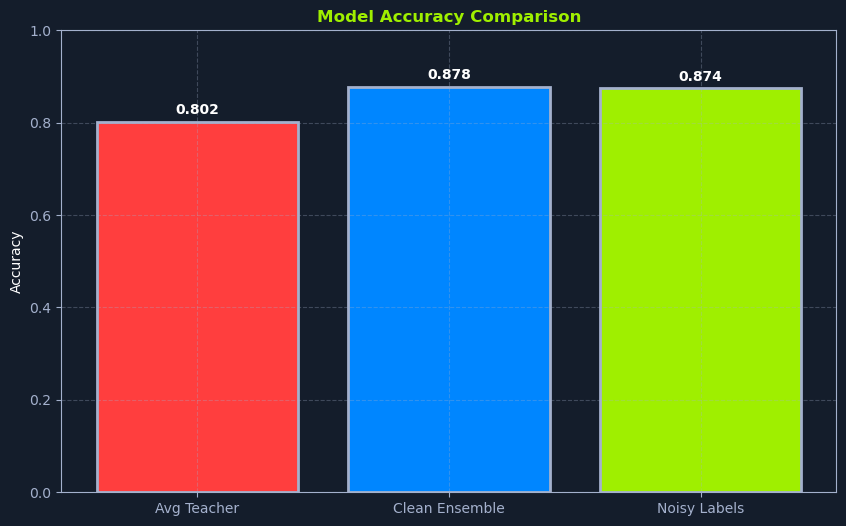

In [18]:
avg_teacher_acc = np.mean([evaluate_accuracy(t, holdout_loader, DEVICE) for t in teachers]) / 100
os.makedirs("figs", exist_ok=True)
plot_accuracy_comparison(
    models=['Avg Teacher', 'Clean Ensemble', 'Noisy Labels'],
    accuracies=[avg_teacher_acc, clean_ensemble_acc / 100, label_accuracy / 100],
    save_path="figs/pate_accuracy_comparison.png"
)

## Training and Deploying the Student Model

In [19]:
print("\n" + "=" * 60)
print("PHASE 4: Training Student Model")
print("=" * 60)

student_model = MLP(
    input_size=num_features,
    hidden_layers=STUDENT_CONFIG['hidden_layers'],
    num_classes=DATASET_CONFIG['num_classes'],
    dropout=STUDENT_CONFIG['dropout']
)

student_train_loader = create_dataloader(
    X_query, student_labels,
    STUDENT_CONFIG['batch_size']
)


PHASE 4: Training Student Model


In [20]:
train_model(
    student_model, student_train_loader, holdout_loader,
    device=DEVICE,
    epochs=STUDENT_CONFIG['epochs'],
    learning_rate=STUDENT_CONFIG['learning_rate']
)

student_test_acc = evaluate_accuracy(student_model, holdout_loader, DEVICE)
print(f"\nPATE student test accuracy: {student_test_acc:.2f}%")

Epoch 1/30: Avg Loss = 0.9956, Test Accuracy = 85.06%
Epoch 2/30: Avg Loss = 0.2282, Test Accuracy = 87.35%
Epoch 3/30: Avg Loss = 0.1709, Test Accuracy = 88.03%
Epoch 4/30: Avg Loss = 0.1391, Test Accuracy = 87.86%
Epoch 5/30: Avg Loss = 0.1190, Test Accuracy = 88.05%
Epoch 6/30: Avg Loss = 0.0986, Test Accuracy = 87.82%
Epoch 7/30: Avg Loss = 0.1033, Test Accuracy = 87.68%
Epoch 8/30: Avg Loss = 0.0985, Test Accuracy = 87.73%
Epoch 9/30: Avg Loss = 0.0791, Test Accuracy = 88.10%
Epoch 10/30: Avg Loss = 0.0629, Test Accuracy = 88.10%
Epoch 11/30: Avg Loss = 0.0651, Test Accuracy = 87.77%
Epoch 12/30: Avg Loss = 0.0603, Test Accuracy = 87.99%
Epoch 13/30: Avg Loss = 0.0526, Test Accuracy = 87.30%
Epoch 14/30: Avg Loss = 0.0452, Test Accuracy = 87.95%
Epoch 15/30: Avg Loss = 0.0394, Test Accuracy = 87.81%
Epoch 16/30: Avg Loss = 0.0352, Test Accuracy = 87.81%
Epoch 17/30: Avg Loss = 0.0364, Test Accuracy = 87.64%
Epoch 18/30: Avg Loss = 0.0366, Test Accuracy = 87.49%
Epoch 19/30: Avg Lo

In [21]:
# Compare against ensemble performance
clean_preds = votes.argmax(axis=1)
clean_ensemble_acc = (clean_preds == y_query_true).mean() * 100
accuracy_gap = clean_ensemble_acc - student_test_acc

print(f"\nComparison:")
print(f"  Clean ensemble accuracy: {clean_ensemble_acc:.2f}%")
print(f"  PATE student accuracy:   {student_test_acc:.2f}%")
print(f"  Accuracy gap:            {accuracy_gap:.2f}%")


Comparison:
  Clean ensemble accuracy: 87.82%
  PATE student accuracy:   87.42%
  Accuracy gap:            0.40%


In [22]:
def deploy_model(model, new_data, scaler, device):
    """
    Deploy the PATE student for inference.

    No privacy budget consumed per query.
    """
    model.eval()
    X_norm = scaler.transform(new_data)
    X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = model(X_tensor)
        predictions = outputs.argmax(dim=1).cpu().numpy()
    
    return predictions
    

In [23]:
# Example deployment
sample_data = X_holdout[:100]
predictions = deploy_model(student_model, sample_data, scaler, DEVICE)
print(f"Processed {len(predictions)} queries with no privacy cost")

Processed 100 queries with no privacy cost


In [24]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

save_file(student_model.state_dict(), os.path.join(MODEL_DIR, "pate_student.safetensors"))
print(f"\nModel saved to {MODEL_DIR}/pate_student.safetensors")


Model saved to models/pate_student.safetensors


## Consensus Analysis and Confident Aggregation

In [25]:
print("\n" + "=" * 60)
print("PHASE 5: Teacher Consensus Analysis")
print("=" * 60)

num_teachers = len(teachers)

# Calculate consensus metrics
max_votes = votes.max(axis=1)

high_threshold = 200  # 80% of 250 teachers
medium_threshold = 150  # 60% of 250 teachers

high_consensus = max_votes >= high_threshold
medium_consensus = (max_votes >= medium_threshold) & ~high_consensus
low_consensus = max_votes < medium_threshold

print(f"\nConsensus Distribution ({num_queries} samples):")
print(f"  High (≥80%):     {high_consensus.sum()} ({100*high_consensus.mean():.1f}%)")
print(f"  Medium (60-80%): {medium_consensus.sum()} ({100*medium_consensus.mean():.1f}%)")
print(f"  Low (<60%):      {low_consensus.sum()} ({100*low_consensus.mean():.1f}%)")


PHASE 5: Teacher Consensus Analysis

Consensus Distribution (5000 samples):
  High (≥80%):     3421 (68.4%)
  Medium (60-80%): 841 (16.8%)
  Low (<60%):      738 (14.8%)


In [26]:
# Calculate clean ensemble accuracy (no noise)
clean_labels = votes.argmax(axis=1)
clean_ensemble_acc = (clean_labels == y_query_true).mean()

# Calculate accuracy by consensus level
def accuracy_for_mask(mask, labels, true_labels):
    if mask.sum() == 0:
        return 0.0
    return (labels[mask] == true_labels[mask]).mean()

clean_high = accuracy_for_mask(high_consensus, clean_labels, y_query_true)
clean_medium = accuracy_for_mask(medium_consensus, clean_labels, y_query_true)
clean_low = accuracy_for_mask(low_consensus, clean_labels, y_query_true)

print(f"\nClean Ensemble Accuracy by Consensus:")
print(f"  High consensus:   {clean_high * 100:.2f}%")
print(f"  Medium consensus: {clean_medium * 100:.2f}%")
print(f"  Low consensus:    {clean_low * 100:.2f}%")
print(f"  Overall:          {clean_ensemble_acc * 100:.2f}%")


Clean Ensemble Accuracy by Consensus:
  High consensus:   97.40%
  Medium consensus: 81.69%
  Low consensus:    50.41%
  Overall:          87.82%


In [27]:
# Apply noisy aggregation
noise_scale = AGGREGATION_CONFIG['noise_scale']
noisy_labels = noisy_argmax(votes, noise_scale)

# Compare to clean predictions
noise_flipped = (noisy_labels != clean_labels)
flip_rate = noise_flipped.mean()

print(f"\nNoisy Aggregation Results (noise_scale={noise_scale}):")
print(f"  Labels matching true:  {(noisy_labels == y_query_true).mean() * 100:.2f}%")
print(f"  Labels matching clean: {(~noise_flipped).mean() * 100:.2f}%")
print(f"  Noise flip rate:       {flip_rate * 100:.2f}%")


Noisy Aggregation Results (noise_scale=20.0):
  Labels matching true:  87.20%
  Labels matching clean: 96.10%
  Noise flip rate:       3.90%


In [28]:
# Flip rate by consensus level
flip_high = noise_flipped[high_consensus].mean()
flip_medium = noise_flipped[medium_consensus].mean()
flip_low = noise_flipped[low_consensus].mean()

print(f"\nNoise Flip Rate by Consensus:")
print(f"  High consensus:   {flip_high * 100:.2f}%")
print(f"  Medium consensus: {flip_medium * 100:.2f}%")
print(f"  Low consensus:    {flip_low * 100:.2f}%")


Noise Flip Rate by Consensus:
  High consensus:   0.00%
  Medium consensus: 0.95%
  Low consensus:    25.34%


In [29]:
def confident_aggregation(votes, noise_scale, threshold):
    """Label only samples where teacher consensus exceeds threshold."""
    max_votes = votes.max(axis=1)
    confident_mask = max_votes >= threshold
    labels = np.full(len(votes), -1, dtype=np.int64)

    if confident_mask.sum() > 0:
        confident_votes = votes[confident_mask]
        noise = np.random.laplace(loc=0.0, scale=noise_scale, size=confident_votes.shape)
        labels[confident_mask] = np.argmax(confident_votes.astype(np.float64) + noise, axis=1)

    return labels, confident_mask

In [30]:
print("\n" + "=" * 60)
print("PHASE 6: Confident Aggregation Analysis")
print("=" * 60)

thresholds = [150, 175, 200, 215, 225]

print(f"\nConfident Aggregation Analysis:")
print(f"{'Threshold':<12} {'Accepted':<12} {'Accuracy':<12} {'ε Saved':<12}")
print("-" * 48)

for threshold in thresholds:
    labels, mask = confident_aggregation(votes, noise_scale, threshold)
    accepted_rate = mask.mean()

    if mask.sum() > 0:
        accuracy = (labels[mask] == y_query_true[mask]).mean() * 100
    else:
        accuracy = 0.0

    epsilon_saved = (1 - accepted_rate) * 100

    print(f"{threshold:<12} {100*accepted_rate:<12.1f}% {accuracy:<12.2f}% {epsilon_saved:<12.1f}%")


PHASE 6: Confident Aggregation Analysis

Confident Aggregation Analysis:
Threshold    Accepted     Accuracy     ε Saved     
------------------------------------------------
150          85.2        % 94.23       % 14.8        %
175          77.7        % 95.78       % 22.3        %
200          68.4        % 97.40       % 31.6        %
215          60.9        % 98.42       % 39.1        %
225          54.7        % 98.76       % 45.3        %


In [31]:
def compute_confident_privacy_budget(num_queries, noise_scale, acceptance_rate, delta=1e-5):
    """Compute privacy budget considering only accepted (labeled) queries."""
    per_query_eps = 2.0 / noise_scale
    effective_queries = int(num_queries * acceptance_rate)
    epsilon_sq_sum = effective_queries * (per_query_eps ** 2)
    total_epsilon = np.sqrt(2 * epsilon_sq_sum * np.log(1 / delta))
    total_epsilon += effective_queries * per_query_eps * (np.exp(per_query_eps) - 1)
    return total_epsilon, per_query_eps, effective_queries


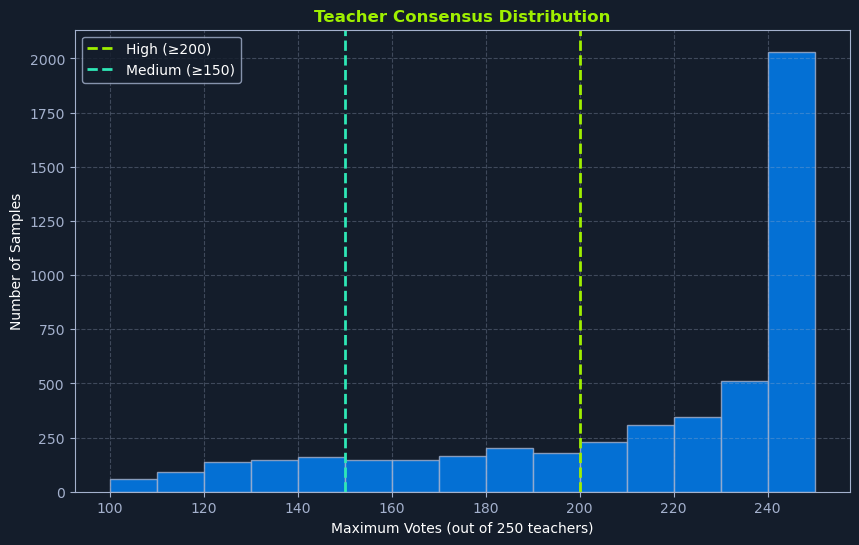

In [32]:
def plot_consensus_distribution(votes, save_path=None):
    """Plot histogram of maximum vote counts with threshold markers."""
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['figsize'])
    max_votes = votes.max(axis=1)
    ax.hist(max_votes, bins=range(100, 251, 10), color=AZURE, edgecolor=HACKER_GREY, alpha=0.8)
    ax.axvline(200, color=HTB_GREEN, linestyle='--', linewidth=2, label='High (≥200)')
    ax.axvline(150, color=AQUAMARINE, linestyle='--', linewidth=2, label='Medium (≥150)')
    ax.set_xlabel('Maximum Votes (out of 250 teachers)')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Teacher Consensus Distribution', color=HTB_GREEN, fontweight='bold')
    ax.legend(framealpha=0.8)
    ax.grid(True, alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight', facecolor=NODE_BLACK)
    plt.show()
    plt.close()

os.makedirs("figs", exist_ok=True)
plot_consensus_distribution(votes, save_path="figs/pate_consensus_distribution.png")

In [33]:
# Evaluate student on samples grouped by original consensus
student_preds = get_model_predictions(student_model, X_query, DEVICE).argmax(axis=1)

student_high = (student_preds[high_consensus] == y_query_true[high_consensus]).mean() * 100
student_medium = (student_preds[medium_consensus] == y_query_true[medium_consensus]).mean() * 100
student_low = (student_preds[low_consensus] == y_query_true[low_consensus]).mean() * 100

print(f"\nStudent Accuracy by Original Consensus:")
print(f"  High consensus samples:   {student_high:.2f}%")
print(f"  Medium consensus samples: {student_medium:.2f}%")
print(f"  Low consensus samples:    {student_low:.2f}%")


Student Accuracy by Original Consensus:
  High consensus samples:   97.40%
  Medium consensus samples: 81.33%
  Low consensus samples:    48.10%


In [34]:
print("\n" + "=" * 60)
print("PHASE 7: Privacy-Utility Tradeoff Analysis")
print("=" * 60)

noise_scales = [5, 10, 20, 40, 80]

print(f"\n{'Noise Scale':<12} {'Per-ε':<10} {'Total ε':<12} {'Label Acc':<12} {'Flip Rate':<12}")
print("-" * 58)

for ns in noise_scales:
    noisy_labels = noisy_argmax(votes, ns)

    per_eps = 2.0 / ns
    total_eps, _ = compute_privacy_budget(num_queries, ns)

    label_acc = (noisy_labels == y_query_true).mean()
    flip_rate = (noisy_labels != clean_labels).mean()

    print(f"{ns:<12} {per_eps:<10.4f} {total_eps:<12.2f} {label_acc:<12.4f} {flip_rate:<12.4f}")


PHASE 7: Privacy-Utility Tradeoff Analysis

Noise Scale  Per-ε      Total ε      Label Acc    Flip Rate   
----------------------------------------------------------
5            0.4000     1119.37      0.8782       0.0108      
10           0.2000     289.26       0.8760       0.0174      
20           0.1000     86.52        0.8702       0.0394      
40           0.0500     29.78        0.8196       0.1120      
80           0.0250     11.65        0.5942       0.3762      


In [36]:
def plot_privacy_utility_tradeoff(noise_scales, votes, y_true, num_queries, save_path=None):
    """Plot privacy vs utility across noise scales on dual axes."""
    accuracies = [(noisy_argmax(votes, ns) == y_true).mean() for ns in noise_scales]
    epsilons = [compute_privacy_budget(num_queries, ns)[0] for ns in noise_scales]

    fig, ax1 = plt.subplots(figsize=PLOT_CONFIG['figsize'])
    ax1.set_xlabel('Noise Scale')
    ax1.set_ylabel('Label Accuracy', color=HTB_GREEN)
    ax1.plot(noise_scales, accuracies, 'o-', color=HTB_GREEN, linewidth=2, markersize=10)
    ax1.tick_params(axis='y', labelcolor=HTB_GREEN)

    ax2 = ax1.twinx()
    ax2.set_ylabel('Privacy Budget (ε)', color=AZURE)
    ax2.plot(noise_scales, epsilons, 's--', color=AZURE, linewidth=2, markersize=10)
    ax2.tick_params(axis='y', labelcolor=AZURE)
    ax2.set_yscale('log')

    ax1.set_title('Privacy-Utility Tradeoff', color=HTB_GREEN, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight', facecolor=NODE_BLACK)
    plt.show()
    plt.close()

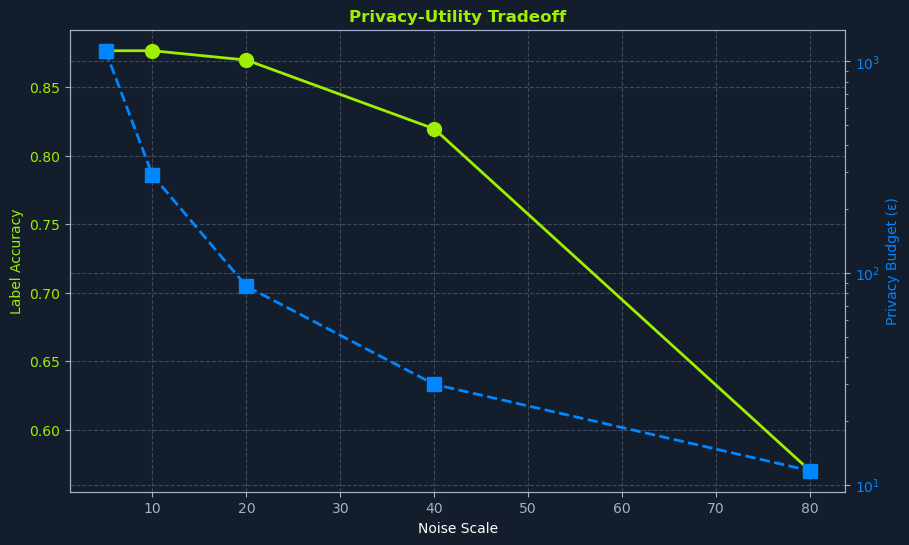

In [37]:
os.makedirs("figs", exist_ok=True)
plot_privacy_utility_tradeoff(noise_scales, votes, y_query_true, num_queries,
                               save_path="figs/pate_privacy_utility.png")

In [38]:
def estimate_queries_for_budget(target_epsilon, noise_scale, delta=1e-5):
    """Binary search for maximum queries within privacy budget."""
    per_query_eps = 2.0 / noise_scale
    low, high = 1, 100000
    while low < high:
        mid = (low + high + 1) // 2
        eps_sq_sum = mid * (per_query_eps ** 2)
        total_eps = np.sqrt(2 * eps_sq_sum * np.log(1 / delta))
        total_eps += mid * per_query_eps * (np.exp(per_query_eps) - 1)
        low, high = (mid, high) if total_eps <= target_epsilon else (low, mid - 1)
    return low

In [39]:
_, confident_mask = confident_aggregation(votes, noise_scale, threshold=200)
acceptance_rate = confident_mask.mean()

target_epsilon = 10.0
standard_queries = estimate_queries_for_budget(target_epsilon, noise_scale)
confident_queries = standard_queries / acceptance_rate

print(f"For ε={target_epsilon}:")
print(f"  Standard aggregation: {standard_queries} queries")
print(f"  Confident (threshold=200): {int(confident_queries)} queries")
print(f"  Net usable labels: {int(confident_queries * acceptance_rate)} samples")

For ε=10.0:
  Standard aggregation: 241 queries
  Confident (threshold=200): 352 queries
  Net usable labels: 241 samples


In [40]:
target_labels = 5000
confident_queries = int(target_labels / acceptance_rate)

conf_eps = compute_confident_privacy_budget(
    confident_queries, noise_scale, acceptance_rate
)[0]

print(f"For {target_labels} labels:")
print(f"  Queries needed: {confident_queries}")
print(f"  Privacy cost: ε = {conf_eps:.2f}")

For 5000 labels:
  Queries needed: 7307
  Privacy cost: ε = 86.50


In [41]:
def iterative_confident_labeling(teachers, X_public, threshold, target_count, noise_scale, device):
    """Query samples until target_count high-consensus labels obtained."""
    confident_X, confident_y, queries_made = [], [], 0
    available_indices = np.random.permutation(len(X_public))

    for idx in available_indices:
        if len(confident_y) >= target_count:
            break
        x = X_public[idx:idx+1]
        labels, mask = confident_aggregation(get_teacher_votes(teachers, x, device), noise_scale, threshold)
        queries_made += 1
        if mask[0]:
            confident_X.append(x[0])
            confident_y.append(labels[0])

    return np.array(confident_X), np.array(confident_y), queries_made

In [42]:
# Information bottleneck metrics
private_data_bytes = len(X_private_norm) * X_private_norm.shape[1] * 4  # float32
student_info_bytes = num_queries * 4  # 4 bits per label, ~0.5 bytes, round to int size
compression_ratio = private_data_bytes / student_info_bytes

print(f"\nInformation Bottleneck:")
print(f"  Private data: {private_data_bytes / 1e6:.1f} MB")
print(f"  Student labels: {student_info_bytes / 1e3:.1f} KB")
print(f"  Compression ratio: {compression_ratio:.0f}:1")


Information Bottleneck:
  Private data: 150.5 MB
  Student labels: 20.0 KB
  Compression ratio: 7526:1


In [43]:
results = {
    'configuration': {'dataset': 'mnist', 'num_teachers': TEACHER_CONFIG['num_teachers'],
                      'noise_scale': AGGREGATION_CONFIG['noise_scale'], 'num_queries': num_queries},
    'privacy': {'per_query_epsilon': float(per_query_eps), 'total_epsilon': float(total_eps)},
    'utility': {'student_accuracy': float(student_test_acc), 'label_accuracy': float(label_accuracy),
                'clean_ensemble_accuracy': float(clean_ensemble_acc)},
    'information': {'private_data_bytes': int(private_data_bytes), 'student_info_bytes': int(student_info_bytes),
                    'compression_ratio': float(compression_ratio)}
}

results_path = os.path.join("figs", "pate_results.json")
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {results_path}")


Results saved to figs/pate_results.json


## PATE Privacy Evaluation

In [45]:
print("\n" + "=" * 60)
print("PHASE 8: Privacy Evaluation")
print("=" * 60)

BASELINE_CONFIG = {
    "hidden_layers": [256, 128],
    "dropout": 0.0,
    "epochs": 50,
    "batch_size": 64,
    "learning_rate": 0.001,
    "train_size": 10000,
}

# Select subset of private data for baseline training
np.random.seed(RANDOM_SEED)
baseline_indices = np.random.choice(
    len(X_private_norm), BASELINE_CONFIG['train_size'], replace=False
)
X_baseline_members = X_private_norm[baseline_indices]
y_baseline_members = y_private[baseline_indices]

# Track which samples are NOT in the baseline training set
baseline_nonmember_mask = np.ones(len(X_private_norm), dtype=bool)
baseline_nonmember_mask[baseline_indices] = False
X_baseline_nonmembers = X_private_norm[baseline_nonmember_mask]
y_baseline_nonmembers = y_private[baseline_nonmember_mask]

print(f"Baseline members: {len(X_baseline_members)} samples")
print(f"Baseline non-members: {len(X_baseline_nonmembers)} samples")


PHASE 8: Privacy Evaluation
Baseline members: 10000 samples
Baseline non-members: 38000 samples


In [46]:

baseline_member_loader = create_dataloader(
    X_baseline_members, y_baseline_members,
    BASELINE_CONFIG['batch_size']
)

baseline_model = MLP(
    input_size=num_features,
    hidden_layers=BASELINE_CONFIG['hidden_layers'],
    num_classes=DATASET_CONFIG['num_classes'],
    dropout=BASELINE_CONFIG['dropout']
)

train_model(
    baseline_model, baseline_member_loader, holdout_loader,
    device=DEVICE,
    epochs=BASELINE_CONFIG['epochs'],
    learning_rate=BASELINE_CONFIG['learning_rate']
)

Epoch 1/50: Avg Loss = 0.5007, Test Accuracy = 93.25%
Epoch 2/50: Avg Loss = 0.1621, Test Accuracy = 94.03%
Epoch 3/50: Avg Loss = 0.0931, Test Accuracy = 94.83%
Epoch 4/50: Avg Loss = 0.0489, Test Accuracy = 94.76%
Epoch 5/50: Avg Loss = 0.0278, Test Accuracy = 95.06%
Epoch 6/50: Avg Loss = 0.0166, Test Accuracy = 95.47%
Epoch 7/50: Avg Loss = 0.0101, Test Accuracy = 95.26%
Epoch 8/50: Avg Loss = 0.0065, Test Accuracy = 95.50%
Epoch 9/50: Avg Loss = 0.0028, Test Accuracy = 95.74%
Epoch 10/50: Avg Loss = 0.0016, Test Accuracy = 95.70%
Epoch 11/50: Avg Loss = 0.0008, Test Accuracy = 95.83%
Epoch 12/50: Avg Loss = 0.0005, Test Accuracy = 95.90%
Epoch 13/50: Avg Loss = 0.0004, Test Accuracy = 95.81%
Epoch 14/50: Avg Loss = 0.0004, Test Accuracy = 95.88%
Epoch 15/50: Avg Loss = 0.0003, Test Accuracy = 95.89%
Epoch 16/50: Avg Loss = 0.0003, Test Accuracy = 95.90%
Epoch 17/50: Avg Loss = 0.0002, Test Accuracy = 95.89%
Epoch 18/50: Avg Loss = 0.0002, Test Accuracy = 95.90%
Epoch 19/50: Avg Lo

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=128, bias=True)
  )
  (dropouts): ModuleList(
    (0-1): 2 x Dropout(p=0.0, inplace=False)
  )
  (output): Linear(in_features=128, out_features=10, bias=True)
)

In [49]:
def compute_mia_advantage(model, X_members, y_members, X_nonmembers, y_nonmembers, device):
    """
    Compute membership inference attack advantage using confidence threshold.
    """
    member_probs = get_model_predictions(model, X_members, device)
    member_confidence = np.max(member_probs, axis=1)

    nonmember_probs = get_model_predictions(model, X_nonmembers, device)
    nonmember_confidence = np.max(nonmember_probs, axis=1)

    n_samples = min(len(member_confidence), len(nonmember_confidence))
    member_conf_balanced = member_confidence[:n_samples]
    nonmember_conf_balanced = nonmember_confidence[:n_samples]

    all_confidence = np.concatenate([member_conf_balanced, nonmember_conf_balanced])
    all_labels = np.concatenate([np.ones(n_samples), np.zeros(n_samples)])

    thresholds = np.percentile(all_confidence, np.linspace(0, 100, 1000))
    best_accuracy = 0.0

    for threshold in thresholds:
        predictions = (all_confidence >= threshold).astype(int)
        accuracy = np.mean(predictions == all_labels)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    attack_advantage = best_accuracy - 0.5
    return best_accuracy, attack_advantage, best_threshold

In [50]:
print("\n--- Attacking Baseline Model ---")
print(f"  Members: {len(X_baseline_members)} samples (baseline training data)")
print(f"  Non-members: {len(X_baseline_nonmembers)} samples")

baseline_mia_acc, baseline_mia_adv, baseline_threshold = compute_mia_advantage(
    baseline_model,
    X_baseline_members, y_baseline_members,
    X_baseline_nonmembers, y_baseline_nonmembers,
    DEVICE
)

print(f"  Attack accuracy:  {baseline_mia_acc:.4f}")
print(f"  Attack advantage: {baseline_mia_adv:.4f}")


--- Attacking Baseline Model ---
  Members: 10000 samples (baseline training data)
  Non-members: 38000 samples
  Attack accuracy:  0.5653
  Attack advantage: 0.0653


In [52]:
print("\n--- Attacking PATE Student Model ---")

student_mia_acc_private, student_mia_adv_private, _ = compute_mia_advantage(
    student_model,
    X_private_norm, y_private,
    X_holdout_norm, y_holdout,
    DEVICE
)

print(f"  Attack accuracy:  {student_mia_acc_private:.4f}")
print(f"  Attack advantage: {student_mia_adv_private:.4f}")



--- Attacking PATE Student Model ---
  Attack accuracy:  0.5007
  Attack advantage: 0.0007


In [54]:
student_mia_acc_query, student_mia_adv_query, _ = compute_mia_advantage(
    student_model,
    X_query, student_labels,
    X_holdout_norm, y_holdout,
    DEVICE
)

print(f"  Attack on query data accuracy:  {student_mia_acc_query:.4f}")
print(f"  Attack on query data advantage: {student_mia_adv_query:.4f}")

  Attack on query data accuracy:  0.5764
  Attack on query data advantage: 0.0764


In [55]:
print("\n" + "-" * 50)
print("SUMMARY: Attack Advantage Comparison")
print("-" * 50)
print(f"  Baseline (no protection):    {baseline_mia_adv:.4f}")
print(f"  PATE Student (private data): {student_mia_adv_private:.4f}")
print(f"  PATE Student (query data):   {student_mia_adv_query:.4f}")

if baseline_mia_adv > 0:
    reduction = (baseline_mia_adv - student_mia_adv_private) / baseline_mia_adv * 100
    print(f"\n  Protection improvement: {reduction:.1f}%")


--------------------------------------------------
SUMMARY: Attack Advantage Comparison
--------------------------------------------------
  Baseline (no protection):    0.0653
  PATE Student (private data): 0.0007
  PATE Student (query data):   0.0764

  Protection improvement: 99.0%


In [57]:
def plot_confidence_distributions(baseline_member, baseline_nonmember,
                                   student_private, student_holdout, save_path=None):
    """Plot density difference between member and non-member confidence."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Baseline model
    bins = np.linspace(0.5, 1.0, 50)
    member_hist, _ = np.histogram(baseline_member, bins=bins, density=True)
    nonmember_hist, _ = np.histogram(baseline_nonmember, bins=bins, density=True)
    diff = member_hist - nonmember_hist
    bin_centers = (bins[:-1] + bins[1:]) / 2

    axes[0].bar(bin_centers, diff, width=0.01, color=MALWARE_RED, alpha=0.8)
    axes[0].axhline(y=0, color=WHITE, linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Prediction Confidence')
    axes[0].set_ylabel('Density Difference (Member - Non-member)')
    axes[0].set_title('Baseline Model', color=MALWARE_RED, fontweight='bold')
    
    # PATE student
    student_member_hist, _ = np.histogram(student_private, bins=bins, density=True)
    student_nonmember_hist, _ = np.histogram(student_holdout, bins=bins, density=True)
    student_diff = student_member_hist - student_nonmember_hist

    axes[1].bar(bin_centers, student_diff, width=0.01, color=HTB_GREEN, alpha=0.8)
    axes[1].axhline(y=0, color=WHITE, linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Prediction Confidence')
    axes[1].set_ylabel('Density Difference (Private - Holdout)')
    axes[1].set_title('PATE Student', color=HTB_GREEN, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight', facecolor=NODE_BLACK)
    plt.show()
    plt.close()

In [59]:
def plot_mia_comparison(baseline_adv, student_adv_private, student_adv_query,
                        baseline_acc, student_acc_private, student_acc_query, save_path=None):
    """Plot bar chart comparing MIA results across models."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    labels = ['Baseline', 'PATE\n(Private)', 'PATE\n(Query)']
    advantages = [baseline_adv, student_adv_private, student_adv_query]
    accuracies = [baseline_acc, student_acc_private, student_acc_query]
    colors = [MALWARE_RED, HTB_GREEN, AQUAMARINE]

    axes[0].bar(labels, advantages, color=colors, edgecolor=HACKER_GREY, linewidth=2)
    axes[0].axhline(y=0.05, color=NUGGET_YELLOW, linestyle='--', linewidth=2, label='5% threshold')
    axes[0].set_ylabel('Attack Advantage')
    axes[0].set_title('MIA Attack Advantage', color=HTB_GREEN, fontweight='bold')
    axes[0].legend()

    axes[1].bar(labels, accuracies, color=colors, edgecolor=HACKER_GREY, linewidth=2)
    axes[1].axhline(y=0.5, color=NUGGET_YELLOW, linestyle='--', linewidth=2, label='Random (50%)')
    axes[1].set_ylabel('Attack Accuracy')
    axes[1].set_title('MIA Attack Accuracy', color=HTB_GREEN, fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight', facecolor=NODE_BLACK)
    plt.show()
    plt.close()


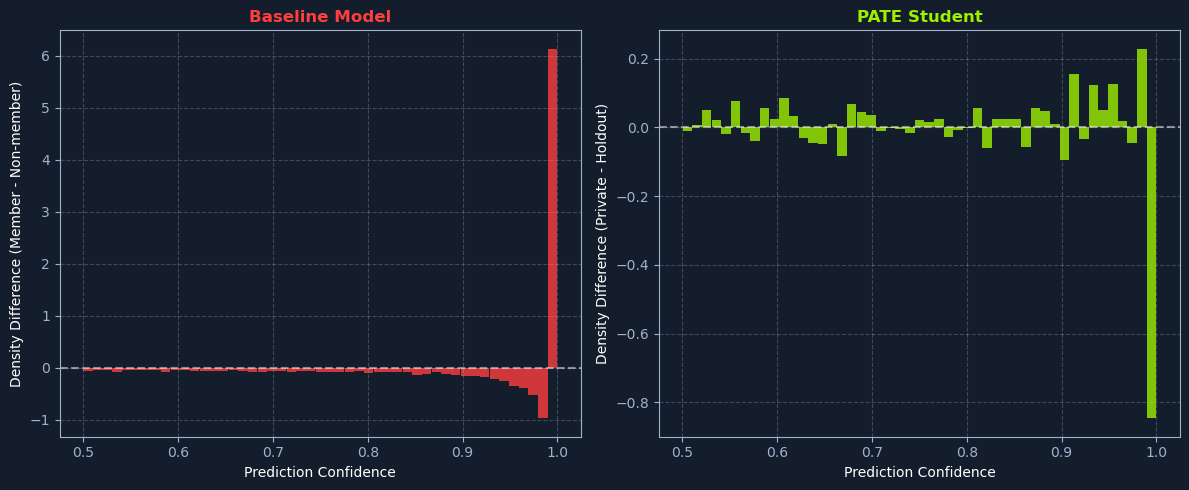

In [60]:
baseline_member_conf = np.max(get_model_predictions(baseline_model, X_baseline_members, DEVICE), axis=1)
baseline_nonmember_conf = np.max(get_model_predictions(baseline_model, X_baseline_nonmembers, DEVICE), axis=1)
student_private_conf = np.max(get_model_predictions(student_model, X_private_norm, DEVICE), axis=1)
student_holdout_conf = np.max(get_model_predictions(student_model, X_holdout_norm, DEVICE), axis=1)

plot_confidence_distributions(
    baseline_member_conf, baseline_nonmember_conf,
    student_private_conf, student_holdout_conf,
    save_path="figs/pate_confidence_distributions.png"
)

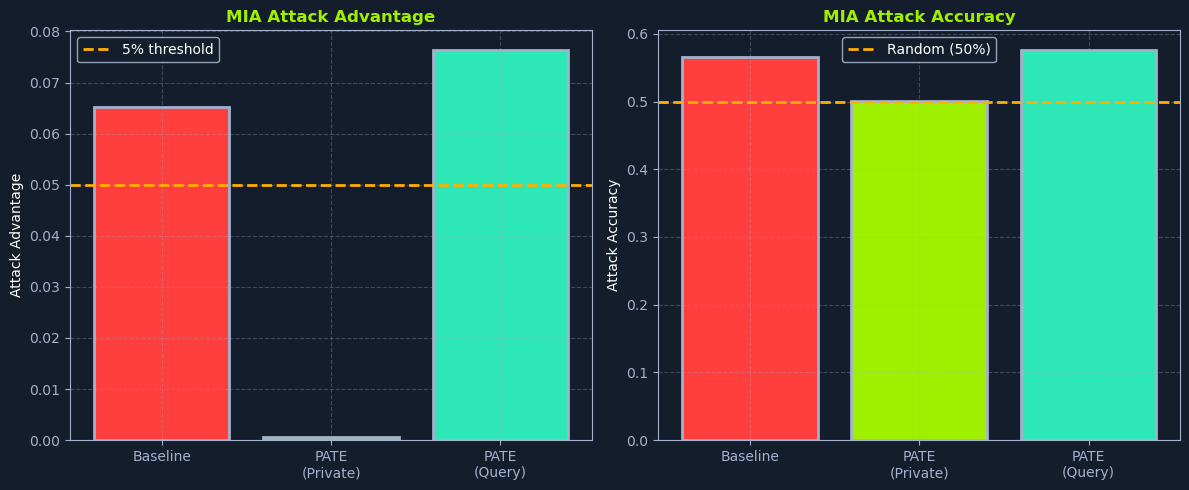

In [61]:
plot_mia_comparison(
    baseline_mia_adv, student_mia_adv_private, student_mia_adv_query,
    baseline_mia_acc, student_mia_acc_private, student_mia_acc_query,
    save_path="figs/pate_mia_comparison.png"
)